In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mdforhadmia/weather-2021-2024-dataset/WEATHER_2021_2024_MERGED.csv


In [2]:
# ===============================
# 1. Import Libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller

In [3]:
# ===============================
# 2. Load Dataset
# ===============================

df = pd.read_csv("/kaggle/input/datasets/mdforhadmia/weather-2021-2024-dataset/WEATHER_2021_2024_MERGED.csv")

df.head()

,DAY,MONTH,YEAR,LAT,LON,HUMIDITY,TEMPERATURE,WIND_SPEED
0,1,1,2021,20.5,88.12,10.47,23.80,4.41
1,1,1,2021,20.5,88.75,10.44,23.63,3.98
2,1,1,2021,20.5,89.38,10.70,23.31,3.73
3,1,1,2021,20.5,90.00,11.23,22.77,3.92
4,1,1,2021,20.5,90.62,11.80,22.47,4.16


In [4]:
# ===============================
# 3. Basic Dataset Check
# ===============================

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nStatistical Summary:")
print(df.describe())

Shape: (105192, 8)

Columns:
Index(['DAY', 'MONTH', 'YEAR', 'LAT', 'LON', 'HUMIDITY', 'TEMPERATURE',
       'WIND_SPEED'],
      dtype='object')

Data Types:
DAY              int64
MONTH            int64
YEAR             int64
LAT            float64
LON            float64
HUMIDITY       float64
TEMPERATURE    float64
WIND_SPEED     float64
dtype: object

Missing Values:
DAY            0
MONTH          0
YEAR           0
LAT            0
LON            0
HUMIDITY       0
TEMPERATURE    0
WIND_SPEED     0
dtype: int64

Duplicate Rows: 0

Statistical Summary:
                 DAY         MONTH           YEAR            LAT  \
count  105192.000000  105192.00000  105192.000000  105192.000000   
mean       15.729637       6.52293    2022.501027      22.500000   
std         8.800134       3.44872       1.118345       1.291001   
min         1.000000       1.00000    2021.000000      20.500000   
25%         8.000000       4.00000    2022.000000      21.500000   
50%        16.000000       7.

In [5]:
# ===============================
# 4. Create Date Column
# ===============================

df['DATE'] = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY']])

df = df.sort_values('DATE')
df = df.set_index('DATE')

df.head()

,DAY,MONTH,YEAR,LAT,LON,HUMIDITY,TEMPERATURE,WIND_SPEED
DATE,,,,,,,,
2021-01-01,1,1,2021,20.5,88.12,10.47,23.80,4.41
2021-01-01,1,1,2021,23.5,90.00,9.16,16.32,2.85
2021-01-01,1,1,2021,23.5,89.38,7.92,15.62,2.88
2021-01-01,1,1,2021,23.5,88.75,7.03,15.43,2.78
2021-01-01,1,1,2021,23.5,88.12,6.75,15.44,2.66


In [6]:
# ===============================
# SORT BY DATE
# ===============================

df = df.sort_values('DATE')

In [7]:
features = ['TEMPERATURE', 'HUMIDITY', 'WIND_SPEED']

data = df[features]

data.head()

,TEMPERATURE,HUMIDITY,WIND_SPEED
DATE,,,
2021-01-01,23.80,10.47,4.41
2021-01-01,23.63,10.44,3.98
2021-01-01,23.31,10.70,3.73
2021-01-01,22.77,11.23,3.92
2021-01-01,22.47,11.80,4.16


   DAY  MONTH  YEAR   LAT    LON  HUMIDITY  TEMPERATURE  WIND_SPEED
0    1      1  2021  20.5  88.12     10.47        23.80        4.41
1    1      1  2021  20.5  88.75     10.44        23.63        3.98
2    1      1  2021  20.5  89.38     10.70        23.31        3.73
3    1      1  2021  20.5  90.00     11.23        22.77        3.92
4    1      1  2021  20.5  90.62     11.80        22.47        4.16
Dataset Shape: (105192, 8)

Columns:
Index(['DAY', 'MONTH', 'YEAR', 'LAT', 'LON', 'HUMIDITY', 'TEMPERATURE',
       'WIND_SPEED'],
      dtype='object')

Data Types:
DAY              int64
MONTH            int64
YEAR             int64
LAT            float64
LON            float64
HUMIDITY       float64
TEMPERATURE    float64
WIND_SPEED     float64
dtype: object

Missing Values:
DAY            0
MONTH          0
YEAR           0
LAT            0
LON            0
HUMIDITY       0
TEMPERATURE    0
WIND_SPEED     0
dtype: int64

Duplicate Rows:
0
   YEAR  MONTH  DAY       DATE
0  2021     

/tmp/ipykernel_23/856470372.py:75: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='bfill')
/tmp/ipykernel_23/856470372.py:76: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill')


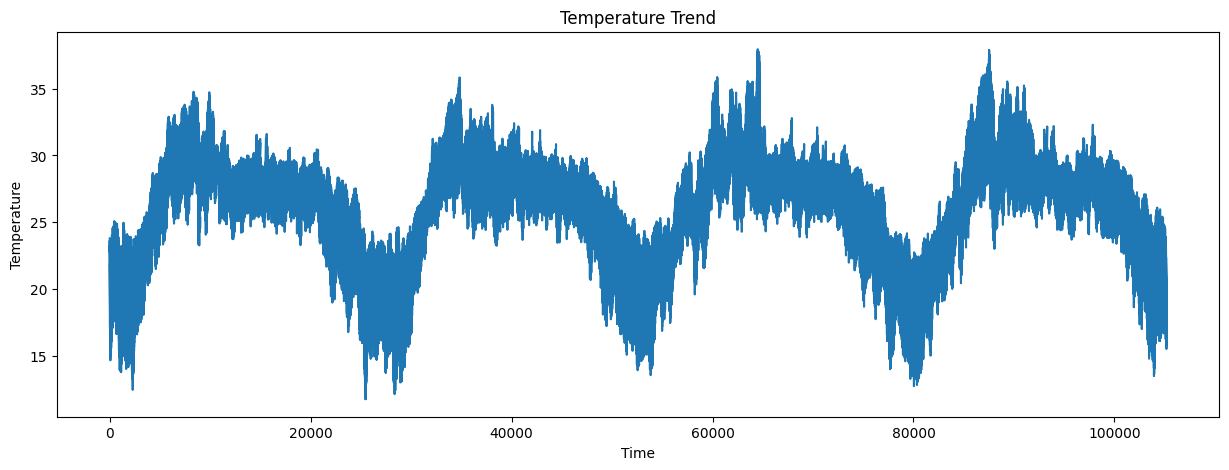

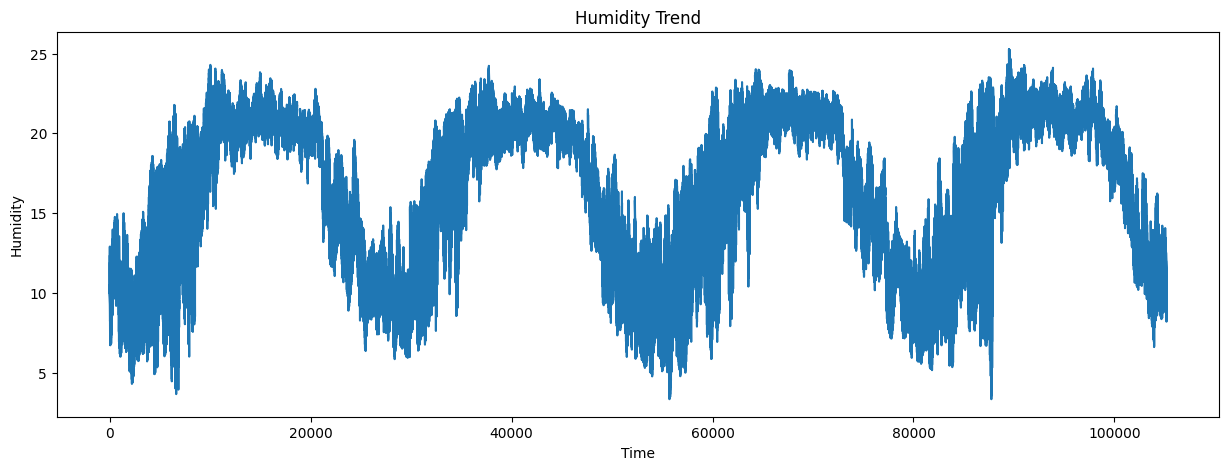

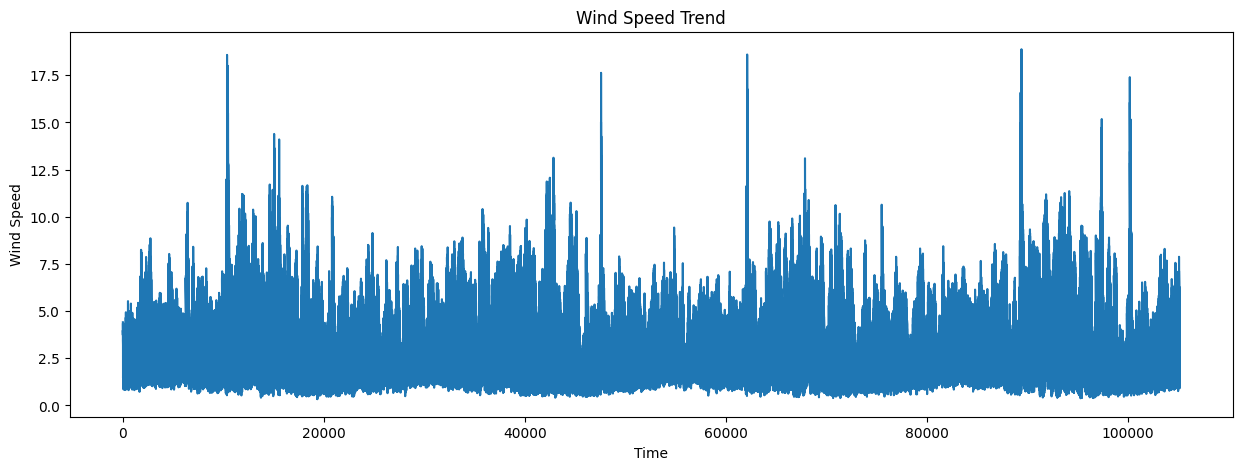

             TEMPERATURE  HUMIDITY  WIND_SPEED
TEMPERATURE     1.000000  0.766427    0.324182
HUMIDITY        0.766427  1.000000    0.379616
WIND_SPEED      0.324182  0.379616    1.000000


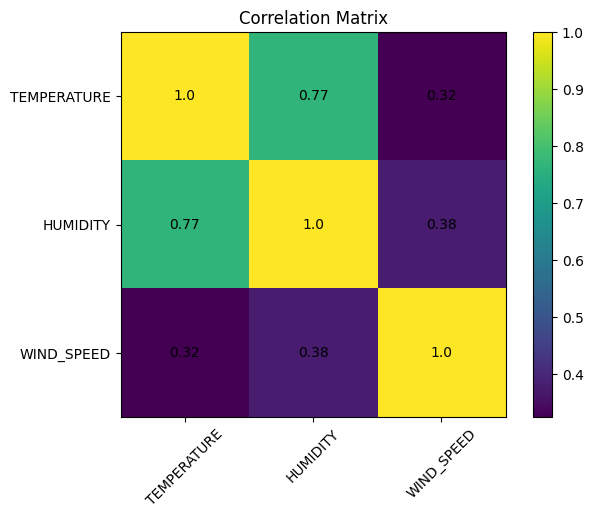


ADF Test for TEMPERATURE
ADF Statistic: -1.9770751145244523
P-value: 0.2967144275546576
Result: Non-Stationary

ADF Test for HUMIDITY
ADF Statistic: -1.8300632434505555
P-value: 0.3656415458649589
Result: Non-Stationary

ADF Test for WIND_SPEED
ADF Statistic: -8.743490562862771
P-value: 2.965277179031041e-14
Result: Stationary
    TEMPERATURE  HUMIDITY  WIND_SPEED
51        -7.48     -1.31       -1.56
50        -0.70     -1.24        0.03
49        -0.19     -0.89       -0.10
48         0.01     -0.28       -0.12
47         3.00      2.59       -1.16

ADF Test for TEMPERATURE_DIFF
ADF Statistic: -152.79419162103986
P-value: 0.0
Result: Stationary

ADF Test for HUMIDITY_DIFF
ADF Statistic: -148.68143603645478
P-value: 0.0
Result: Stationary

ADF Test for WIND_SPEED_DIFF
ADF Statistic: -115.72833491698472
P-value: 0.0
Result: Stationary
Datasets Saved Successfully!


In [8]:

# =====================================================
# 1. IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller


# =====================================================
# 2. LOAD DATASET
# =====================================================

df = pd.read_csv("/kaggle/input/datasets/mdforhadmia/weather-2021-2024-dataset/WEATHER_2021_2024_MERGED.csv")

print(df.head())


# =====================================================
# 3. DATASET INFORMATION
# =====================================================

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


# =====================================================
# 4. CREATE DATE COLUMN
# =====================================================

df['DATE'] = pd.to_datetime(
    df[['YEAR', 'MONTH', 'DAY']]
)

print(df[['YEAR','MONTH','DAY','DATE']].head())


# =====================================================
# 5. SORT DATA BY DATE
# =====================================================

df = df.sort_values('DATE')

print(df.head())

# =====================================================
# 6. SELECT FEATURES
# =====================================================

features = ['TEMPERATURE', 'HUMIDITY', 'WIND_SPEED']

data = df[features]

print(data.head())

# =====================================================
# 7. HANDLE MISSING VALUES
# =====================================================

data = data.interpolate(method='linear')

data = data.fillna(method='bfill')
data = data.fillna(method='ffill')

print(data.isnull().sum())


# =====================================================
# 8. STATISTICAL SUMMARY
# =====================================================

print(data.describe())


# =====================================================
# 9. VISUALIZE TEMPERATURE
# =====================================================

plt.figure(figsize=(15,5))

plt.plot(data['TEMPERATURE'])

plt.title("Temperature Trend")
plt.xlabel("Time")
plt.ylabel("Temperature")

plt.show()


# =====================================================
# 10. VISUALIZE HUMIDITY
# =====================================================

plt.figure(figsize=(15,5))

plt.plot(data['HUMIDITY'])

plt.title("Humidity Trend")
plt.xlabel("Time")
plt.ylabel("Humidity")

plt.show()


# =====================================================
# 11. VISUALIZE WIND SPEED
# =====================================================

plt.figure(figsize=(15,5))

plt.plot(data['WIND_SPEED'])

plt.title("Wind Speed Trend")
plt.xlabel("Time")
plt.ylabel("Wind Speed")

plt.show()


# =====================================================
# 12. CORRELATION MATRIX
# =====================================================

corr = data.corr()

print(corr)

plt.figure(figsize=(7,5))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(features)), features, rotation=45)
plt.yticks(range(len(features)), features)

for i in range(len(features)):
    for j in range(len(features)):
        plt.text(j, i, round(corr.iloc[i, j], 2),
                 ha='center', va='center')

plt.title("Correlation Matrix")

plt.show()


# =====================================================
# 13. ADF TEST FUNCTION
# =====================================================

def adf_test(series, name):

    result = adfuller(series.dropna())

    print(f"\nADF Test for {name}")

    print("ADF Statistic:", result[0])

    print("P-value:", result[1])

    if result[1] <= 0.05:
        print("Result: Stationary")

    else:
        print("Result: Non-Stationary")


# =====================================================
# 14. RUN ADF TEST
# =====================================================

for col in features:

    adf_test(data[col], col)



# =====================================================
# 15. DIFFERENCING
# =====================================================

diff_data = data.diff().dropna()

print(diff_data.head())



# =====================================================
# 16. ADF TEST AFTER DIFFERENCING
# =====================================================

for col in features:

    adf_test(diff_data[col], col + "_DIFF")



# =====================================================
# 17. SAVE CLEAN DATASET
# =====================================================

data.to_csv("/kaggle/working/clean_weather_dataset.csv")

diff_data.to_csv("/kaggle/working/differenced_weather_dataset.csv")

print("Datasets Saved Successfully!")



**LSTM TRAIN**

In [9]:
# =====================================================
# 18. IMPORT SCALER
# =====================================================

from sklearn.preprocessing import MinMaxScaler
# =====================================================
# 19. SCALE DATA
# =====================================================

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

print(scaled_data.shape)
# =====================================================
# 20. CONVERT TO DATAFRAME
# =====================================================

scaled_df = pd.DataFrame(
    scaled_data,
    columns=features
)

print(scaled_df.head())
sequence_length = 30
# =====================================================
# 21. CREATE SEQUENCES
# =====================================================

X = []
y = []

sequence_length = 30

for i in range(sequence_length, len(scaled_df)):

    X.append(
        scaled_df.iloc[i-sequence_length:i].values
    )

    y.append(
        scaled_df.iloc[i].values
    )

X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)
# =====================================================
# 22. TRAIN TEST SPLIT
# =====================================================

split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
# =====================================================
# 23. SAVE NUMPY ARRAYS
# =====================================================

np.save("/kaggle/working/X_train.npy", X_train)
np.save("/kaggle/working/X_test.npy", X_test)

np.save("/kaggle/working/y_train.npy", y_train)
np.save("/kaggle/working/y_test.npy", y_test)

print("Training arrays saved successfully!")
# =====================================================
# 23. SAVE NUMPY ARRAYS
# =====================================================

np.save("/kaggle/working/X_train.npy", X_train)
np.save("/kaggle/working/X_test.npy", X_test)

np.save("/kaggle/working/y_train.npy", y_train)
np.save("/kaggle/working/y_test.npy", y_test)

print("Training arrays saved successfully!")

(105192, 3)
   TEMPERATURE  HUMIDITY  WIND_SPEED
0     0.459717  0.325433    0.219946
1     0.174112  0.265725    0.135849
2     0.147384  0.209207    0.137466
3     0.140130  0.168642    0.132075
4     0.140512  0.155880    0.125606
X Shape: (105162, 30, 3)
y Shape: (105162, 3)
X_train: (84129, 30, 3)
X_test: (21033, 30, 3)
y_train: (84129, 3)
y_test: (21033, 3)
Training arrays saved successfully!
Training arrays saved successfully!


2026-05-25 05:15:31.277739: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779686131.876855      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779686132.082312      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779686133.305920      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779686133.305956      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779686133.305959      23 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,979 (121.01 KB)

 Trainable params: 30,979 (121.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


I0000 00:00:1779686178.173116      75 cuda_dnn.cc:529] Loaded cuDNN version 91002


1052/1052 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 0.0156 - val_loss: 0.0043
Epoch 2/50
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0052 - val_loss: 0.0041
Epoch 3/50
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0047 - val_loss: 0.0038
Epoch 4/50
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0044 - val_loss: 0.0038
Epoch 5/50
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0041 - val_loss: 0.0036
Epoch 6/50
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0040 - val_loss: 0.0032
Epoch 7/50
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0038 - val_loss: 0.0031
Epoch 8/50
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0038 - val_loss: 0.0033
Epoch 9/50
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0037 - val_loss: 0.0031
Epoch 10/50
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0036 - val_loss: 0.0033
Epoch 11/50
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0035 - val_loss: 0.0029
Epoch 12/50
1052/1052 ━━━━━━━━━━━━━━━━━━

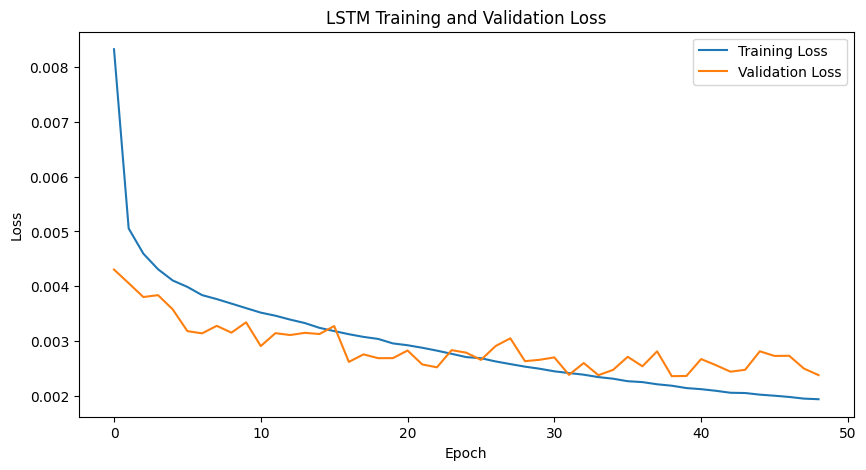

In [10]:
# =====================================================
# 24. IMPORT DEEP LEARNING LIBRARIES
# =====================================================

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# =====================================================
# 25. BUILD LSTM MODEL
# =====================================================

model_lstm = Sequential()

model_lstm.add(
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2]))
)

model_lstm.add(Dropout(0.2))

model_lstm.add(
    LSTM(32, return_sequences=False)
)

model_lstm.add(Dropout(0.2))

model_lstm.add(Dense(32, activation='relu'))

model_lstm.add(Dense(3))

model_lstm.compile(
    optimizer='adam',
    loss='mse'
)

model_lstm.summary()
# =====================================================
# 26. TRAIN LSTM MODEL
# =====================================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_lstm = model_lstm.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)
# =====================================================
# 27. PLOT TRAINING LOSS
# =====================================================

plt.figure(figsize=(10,5))

plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

658/658 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
(21033, 3)
[[27.12 19.05  4.53]
 [28.56 17.01  3.54]
 [28.54 17.15  3.73]
 [25.82 12.5   1.02]
 [25.09 17.07  1.5 ]]
[[27.236534  16.698748   2.801873 ]
 [27.784714  16.55161    3.1522188]
 [27.927412  15.695179   3.0082707]
 [25.762535  14.607416   1.5642304]
 [26.256172  16.37378    2.898769 ]]

Results for TEMPERATURE
MAE : 0.8581058001478575
MSE : 1.292387512864758
RMSE: 1.1368322272282563
R2 Score: 0.8970926864518526

Results for HUMIDITY
MAE : 1.094856715076508
MSE : 1.756776202213506
RMSE: 1.325434344738926
R2 Score: 0.9034849565242232

Results for WIND_SPEED
MAE : 0.6974465278053602
MSE : 1.012036243448914
RMSE: 1.006000120998459
R2 Score: 0.7900553499895473


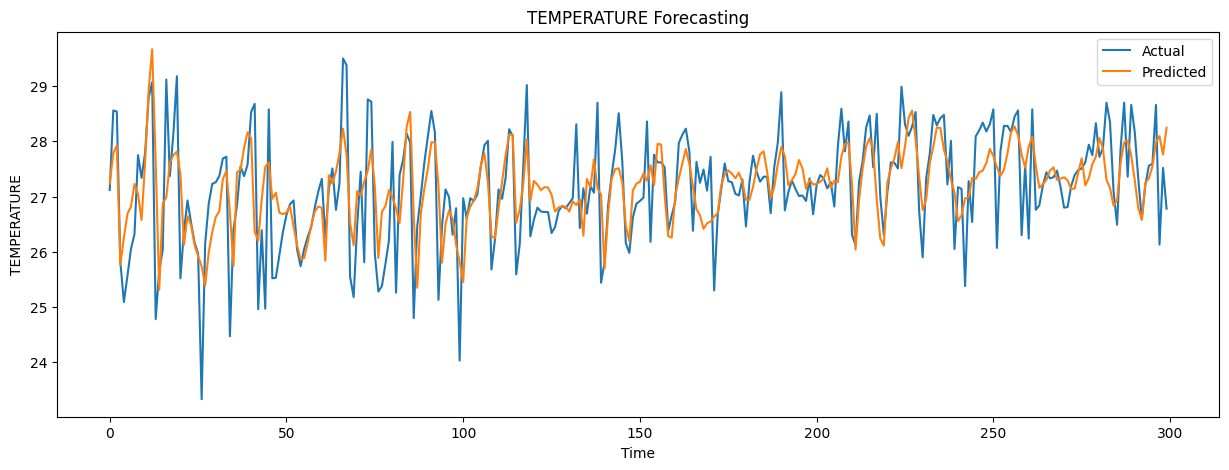

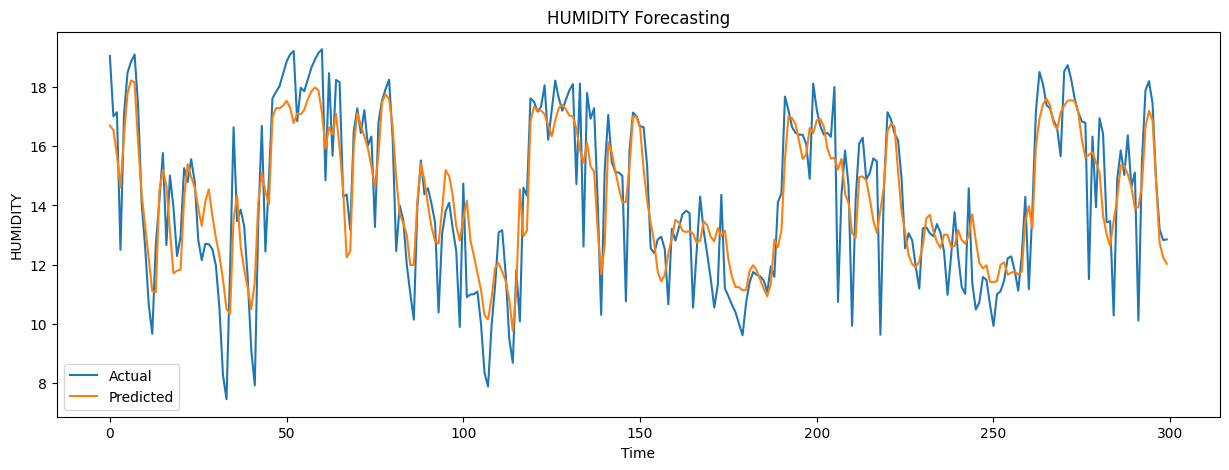

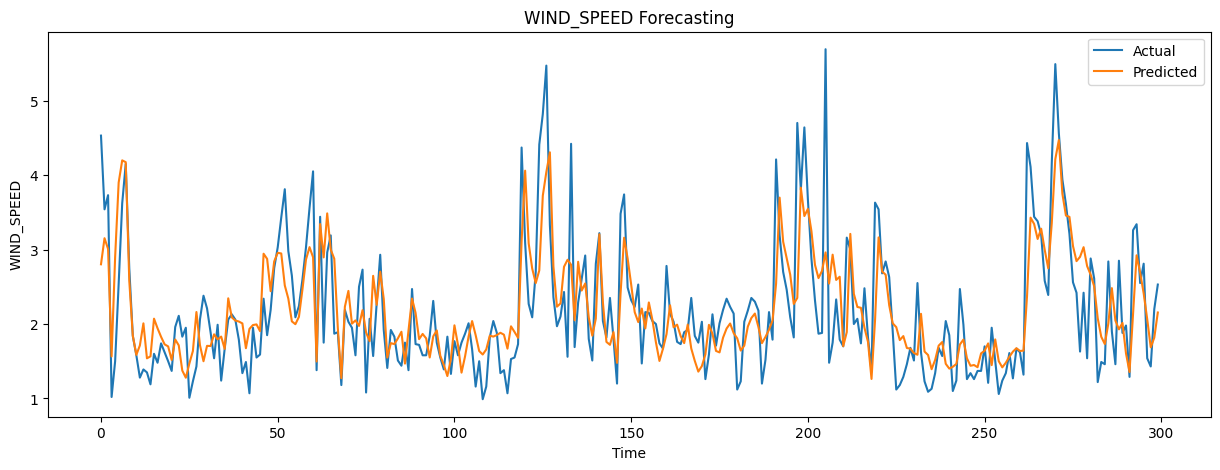

In [11]:
y_pred_lstm = model_lstm.predict(X_test)

print(y_pred_lstm.shape)
y_test_actual = scaler.inverse_transform(y_test)

y_pred_actual = scaler.inverse_transform(y_pred_lstm)

print(y_test_actual[:5])
print(y_pred_actual[:5])
# =====================================================
# 30. EVALUATION METRICS
# =====================================================

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

features = ['TEMPERATURE', 'HUMIDITY', 'WIND_SPEED']

for i, col in enumerate(features):

    mae = mean_absolute_error(
        y_test_actual[:, i],
        y_pred_actual[:, i]
    )

    mse = mean_squared_error(
        y_test_actual[:, i],
        y_pred_actual[:, i]
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test_actual[:, i],
        y_pred_actual[:, i]
    )

    print(f"\nResults for {col}")

    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    # =====================================================
# 31. ACTUAL VS PREDICTED
# =====================================================

for i, col in enumerate(features):

    plt.figure(figsize=(15,5))

    plt.plot(
        y_test_actual[:300, i],
        label='Actual'
    )

    plt.plot(
        y_pred_actual[:300, i],
        label='Predicted'
    )

    plt.title(f"{col} Forecasting")

    plt.xlabel("Time")

    plt.ylabel(col)

    plt.legend()

    plt.show()

In [12]:
# =====================================================
# 32. SAVE LSTM MODEL
# =====================================================

model_lstm.save("/kaggle/working/lstm_weather_model.h5")

print("LSTM Model Saved Successfully!")

LSTM Model Saved Successfully!


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 30, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 30, 64)    │        256 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 64)    │     16,640 │ dense_2[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 30, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 64)    │          0 │ dense_2[0][0],    │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 30, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 30, 128)   │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 30, 64)    │      8,256 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 30, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 30, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 64)        │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 3)         │        195 │ dropout_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 54,851 (214.26 KB)

 Trainable params: 54,851 (214.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


I0000 00:00:1779686616.269392      73 service.cc:152] XLA service 0x7da894ee3cd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779686616.269452      73 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779686616.269459      73 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


  33/1052 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.2531

I0000 00:00:1779686622.534929      73 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1052/1052 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - loss: 0.0329 - val_loss: 0.0051
Epoch 2/50
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0085 - val_loss: 0.0048
Epoch 3/50
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0076 - val_loss: 0.0052
Epoch 4/50
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0073 - val_loss: 0.0049
Epoch 5/50
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0071 - val_loss: 0.0048
Epoch 6/50
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0069 - val_loss: 0.0051
Epoch 7/50
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0068 - val_loss: 0.0044
Epoch 8/50
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0068 - val_loss: 0.0043
Epoch 9/50
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0067 - val_loss: 0.0043
Epoch 10/50
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0066 - val_loss: 0.0042
Epoch 11/50
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0066 - val_loss: 0.0045
Epoch 12/50
1052/1052 ━━━━━━━━━━━━━━━━━

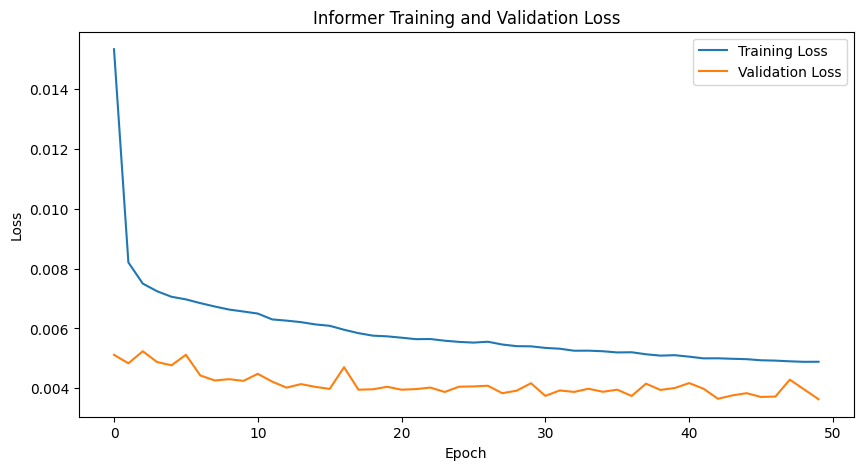

In [13]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
# =====================================================
# 33. BUILD INFORMER-STYLE TRANSFORMER MODEL
# =====================================================

def build_informer_model(input_shape, output_dim):
    
    inputs = Input(shape=input_shape)

    # Input projection
    x = Dense(64)(inputs)

    # Attention Block 1
    attn_output = MultiHeadAttention(
        num_heads=4,
        key_dim=16
    )(x, x)

    attn_output = Dropout(0.2)(attn_output)
    x = LayerNormalization()(x + attn_output)

    # Feed Forward Network
    ffn = Dense(128, activation='relu')(x)
    ffn = Dropout(0.2)(ffn)
    ffn = Dense(64)(ffn)

    x = LayerNormalization()(x + ffn)

    # Attention Block 2
    attn_output = MultiHeadAttention(
        num_heads=4,
        key_dim=16
    )(x, x)

    attn_output = Dropout(0.2)(attn_output)
    x = LayerNormalization()(x + attn_output)

    # Global pooling
    x = GlobalAveragePooling1D()(x)

    # Dense Layers
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)

    outputs = Dense(output_dim)(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer='adam',
        loss='mse'
    )

    return model
    # =====================================================
# 34. CREATE INFORMER MODEL
# =====================================================

model_informer = build_informer_model(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    output_dim=3
)

model_informer.summary()
# =====================================================
# 35. TRAIN INFORMER MODEL
# =====================================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_informer = model_informer.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)
# =====================================================
# 36. PLOT INFORMER TRAINING LOSS
# =====================================================

plt.figure(figsize=(10,5))

plt.plot(history_informer.history['loss'], label='Training Loss')
plt.plot(history_informer.history['val_loss'], label='Validation Loss')

plt.title("Informer Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

658/658 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
(21033, 3)
[[27.12 19.05  4.53]
 [28.56 17.01  3.54]
 [28.54 17.15  3.73]
 [25.82 12.5   1.02]
 [25.09 17.07  1.5 ]]
[[26.249735  16.251202   2.792569 ]
 [26.448015  16.047155   2.7913315]
 [26.317654  15.518745   2.655573 ]
 [27.065075  15.879058   2.8536284]
 [27.038544  16.206161   2.9419565]]

Results for TEMPERATURE
MAE : 1.0087548381399338
MSE : 2.054199972511193
RMSE: 1.4332480498891993
R2 Score: 0.8364328047450531

Results for HUMIDITY
MAE : 1.045093075463839
MSE : 2.8099872476753807
RMSE: 1.6763016577201673
R2 Score: 0.8456228852405598

Results for WIND_SPEED
MAE : 1.1886886419470286
MSE : 2.623938394705177
RMSE: 1.6198575229646517
R2 Score: 0.45566986213060945


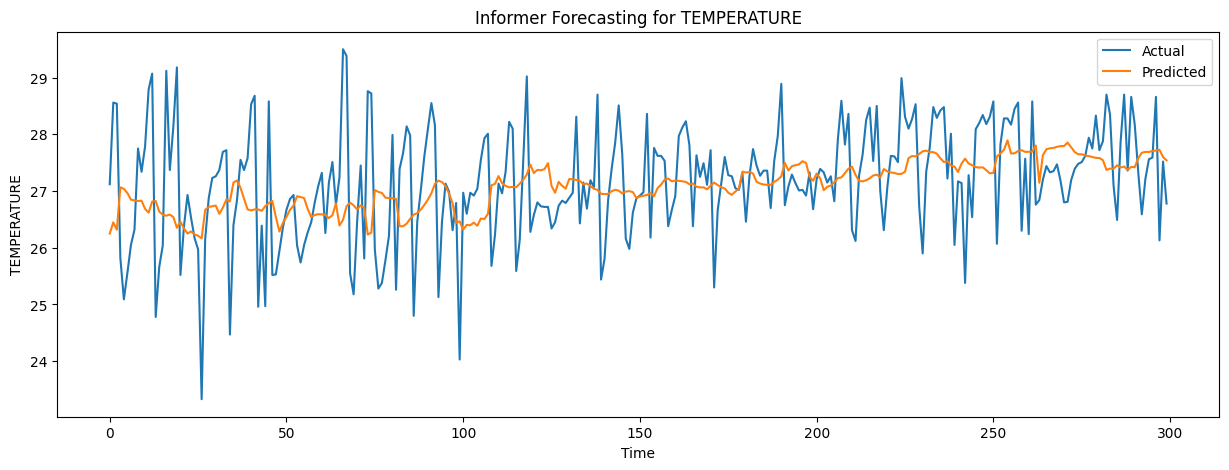

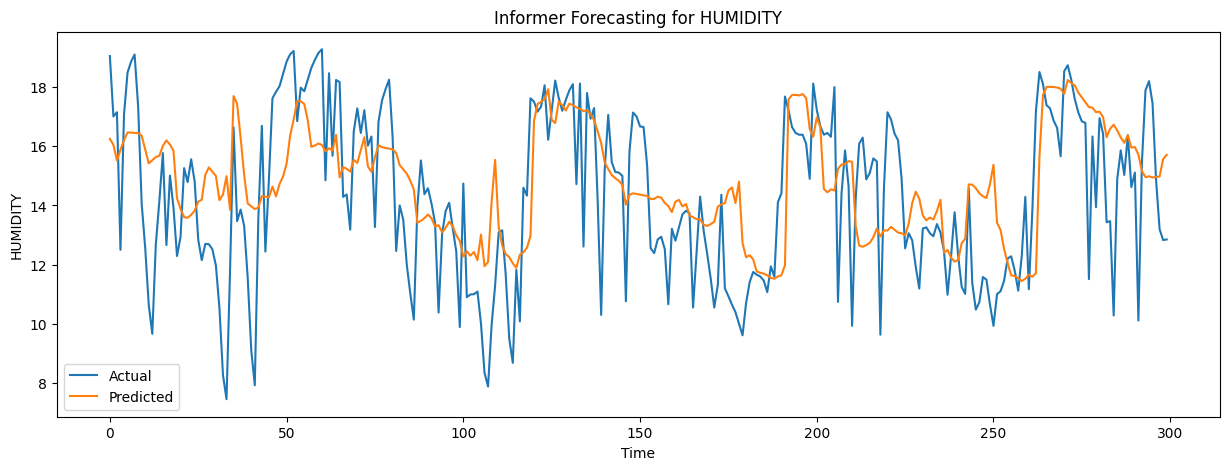

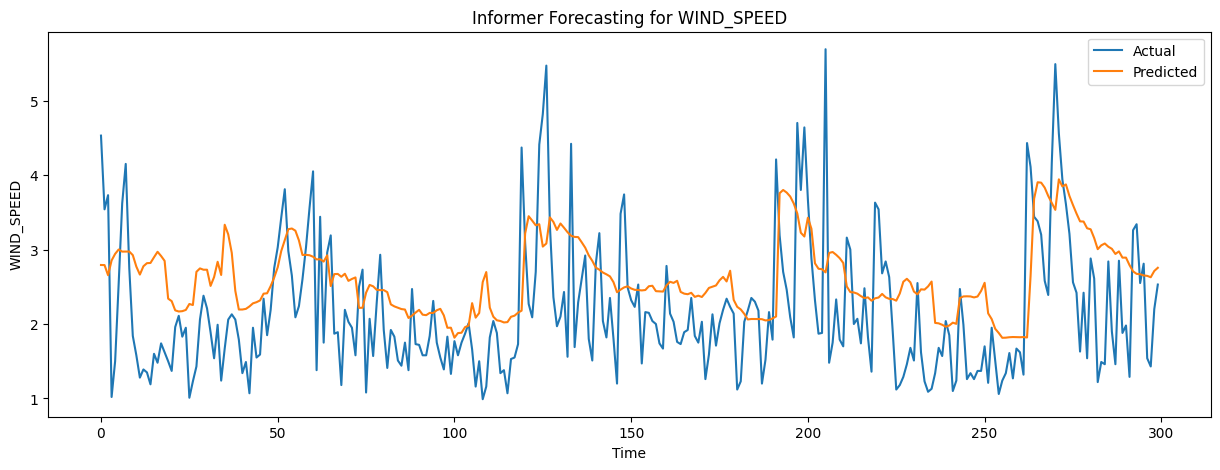

In [14]:
# =====================================================
# 37. PREDICT USING INFORMER
# =====================================================

y_pred_informer = model_informer.predict(X_test)

print(y_pred_informer.shape)
# =====================================================
# 38. INVERSE TRANSFORM
# =====================================================

y_test_actual = scaler.inverse_transform(y_test)

y_pred_informer_actual = scaler.inverse_transform(
    y_pred_informer
)

print(y_test_actual[:5])
print(y_pred_informer_actual[:5])
# =====================================================
# 39. INFORMER EVALUATION
# =====================================================

features = ['TEMPERATURE', 'HUMIDITY', 'WIND_SPEED']

for i, col in enumerate(features):

    mae = mean_absolute_error(
        y_test_actual[:, i],
        y_pred_informer_actual[:, i]
    )

    mse = mean_squared_error(
        y_test_actual[:, i],
        y_pred_informer_actual[:, i]
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test_actual[:, i],
        y_pred_informer_actual[:, i]
    )

    print(f"\nResults for {col}")

    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    # =====================================================
# 40. ACTUAL VS PREDICTED
# =====================================================

for i, col in enumerate(features):

    plt.figure(figsize=(15,5))

    plt.plot(
        y_test_actual[:300, i],
        label='Actual'
    )

    plt.plot(
        y_pred_informer_actual[:300, i],
        label='Predicted'
    )

    plt.title(f"Informer Forecasting for {col}")

    plt.xlabel("Time")

    plt.ylabel(col)

    plt.legend()

    plt.show()